# VQC Based on IQC

## Imports

In [1]:
import qiskit
from qiskit_machine_learning.algorithms import VQC
from qiskit.circuit import QuantumCircuit,Parameter
from qiskit.compiler import transpile
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram, visualize_transition, plot_bloch_vector
from qiskit.circuit.library import UnitaryGate,Initialize
from qiskit.quantum_info import Statevector,partial_trace, DensityMatrix

import pennylane as qml
from pennylane import numpy as pnp
import qutip
from toqito import state_props

import numpy as np
from scipy.linalg import expm as expMatrix
from sympy.physics.quantum.dagger import Dagger
import math

from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold,train_test_split, KFold
from sklearn.multiclass import OneVsRestClassifier
from sklearn.utils.multiclass import unique_labels
from sklearn.utils.validation import check_array, check_is_fitted
from sklearn.preprocessing import MinMaxScaler
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn import preprocessing
from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score, make_scorer, roc_auc_score, classification_report

from ucimlrepo import fetch_ucirepo

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pdflatex

import pandas as pd


## Base de Dados

In [2]:
#Gerando o dataset
bc = fetch_ucirepo(id=17)
# data (as pandas dataframes) 
X_bc = bc.data.features 
X_bc = X_bc.values
y_bc = bc.data.targets
y_bc = y_bc.values

#Parâmetros
RANDOM_SEED = 1
LEARNING_RATE = 0.01
N_FEATURES = len(X_bc[0])
N_SAMPLES = len(X_bc)
N_PRINTINGS = N_SAMPLES//2
N_QUBITS=math.ceil(np.log2(N_FEATURES)+1) #Nqubits do circuito
weights=np.full(N_FEATURES,1)
QUBITS=[i for i in range(N_QUBITS)]
N_ITER=200
N_SHOTS=2048

## Tratamento do Dataset

In [3]:
def normalize_iqc(data, normalize_col=False, normalize_lin=False):
    if normalize_col:
        scaler = MinMaxScaler() #Normaliza a coluna entre [0,1]
        scaler.fit(data)
        data = scaler.transform(data)
        data = data - 1
    if normalize_lin:
        data = preprocessing.normalize(data,axis=1,norm='l2') #Normalize the line between [-1,1]
    return data

X_bc_iqc_coluna=normalize_iqc(X_bc, normalize_col=True)
X_bc_iqc_linha=normalize_iqc(X_bc, normalize_lin=True)

#### Boxplot Dataset Column Normalized

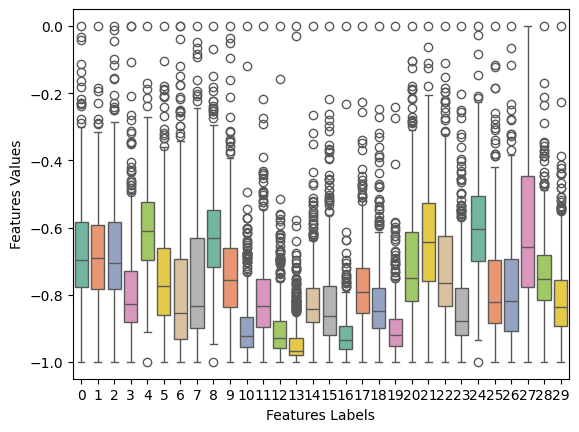

In [4]:
fig, ax = plt.subplots()
sns.boxplot(X_bc_iqc_coluna, palette="Set2",ax=ax)
ax.set_xlabel('Features Labels')
ax.set_ylabel('Features Values')
plt.savefig('boxplot_bc_iqc_coluna.svg')

#### Boxplot Dataset Line Normalized

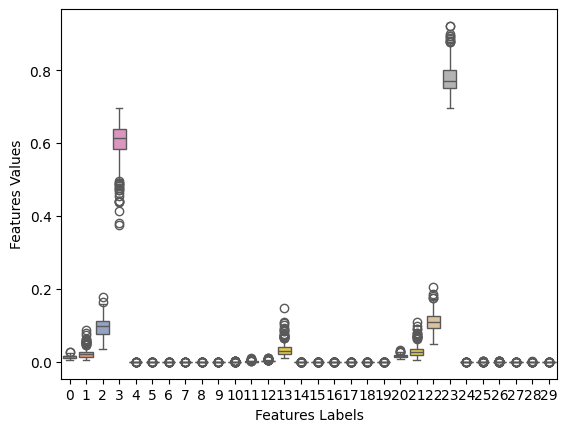

In [5]:
fig, ax = plt.subplots()
sns.boxplot(X_bc_iqc_linha, palette="Set2",ax=ax)
ax.set_xlabel('Features Labels')
ax.set_ylabel('Features Values')
plt.savefig('boxplot_bc_iqc_linha.svg')

## Quantum Circuit

Não geraremos imagens ainda

### Circuito IQC em Pennylane

Ainda em construção

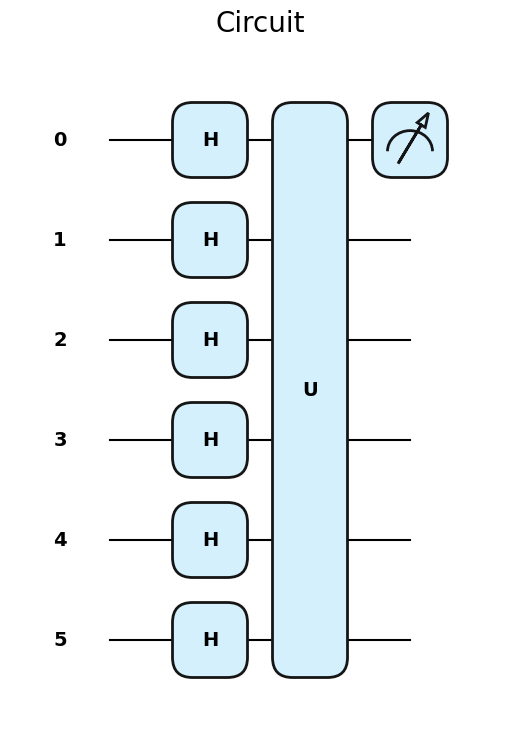

In [9]:
N_atributos=N_FEATURES 
'''
Numero de atributos do vetor a ser classificado. Adicionamos mais 1 ao numero obtido antes(pois temos o qubit alvo)
'''
#Escolhendo uma linha aleatória de X para podermos debugar
lista=[i for i in range(len(X_bc))]
j=int(np.random.choice(lista))

w=weights

#x=np.random.rand(N_atributos)
#w=np.random.rand(N_atributos)

N_qubits=math.ceil(np.log2(N_atributos)+1) #Nqubits do circuito

#Podíamos inicializar assim pra facilitar as contas
'''x=np.random.rand(2**N_atributos)
w=np.random.rand(2**N_atributos)'''

#Montando os sigmas

matriz_pauli_x=np.array([[0,1],[1,0]]) # Matriz de Pauli x
matriz_pauli_y=np.array([[0,-1j],[1j,0]]) # Matriz de Pauli y
matriz_pauli_z=np.array([[1,0],[0,-1]]) # Matriz de Pauli z

sigmaQ=matriz_pauli_x+matriz_pauli_y+matriz_pauli_z



X_bc_new=list(X_bc[j])
if np.log2(N_atributos)%2!=0 and np.log2(N_atributos)!=1:
    for k in range(2**(N_qubits-1) - N_atributos):
        X_bc_new.append(0)
        w=np.append(w,0)
    sigmaE=np.diag(X_bc_new)*w.T
else:
    sigmaE=np.diag(X_bc_new)*w.T

#Operador Unitário
U=pnp.matrix(expMatrix(1j*pnp.kron(sigmaQ,sigmaE)))
#U=np.array([[1,0,0,0],[0,1,0,0],[0,0,0,1],[0,0,1,0]])

#tem que inicializar o device
qubits=[i for i in range(N_qubits)]
dev = qml.device("default.qubit", wires = qubits)

@qml.qnode(dev)
def circuit():

    #https://docs.pennylane.ai/en/stable/introduction/operations.html lista dos operadores do pennylane
    #colocar as portas aq
    for i in range(N_qubits):
        qml.Hadamard(wires=[i])
    qml.QubitUnitary(U, wires=qubits)

    return qml.density_matrix([0]) #Retorna a matriz reduzida do qubit alvo

state=circuit
#print(state())
qml.drawer.use_style('pennylane')
fig, ax = qml.draw_mpl(circuit)()
ax.set_aspect('equal')
fig.set_figwidth(20)
plt.title("Circuit",size = 20)
plt.show()

In [10]:
print(U.shape)

(64, 64)


### Circuito IQC em Qiskit

X[458]: [np.float64(13.0), np.float64(25.13), np.float64(82.61), np.float64(520.2), np.float64(0.08369), np.float64(0.05073), np.float64(0.01206), np.float64(0.01762), np.float64(0.1667), np.float64(0.05449), np.float64(0.2621), np.float64(1.232), np.float64(1.657), np.float64(21.19), np.float64(0.006054), np.float64(0.008974), np.float64(0.005681), np.float64(0.006336), np.float64(0.01215), np.float64(0.001514), np.float64(14.34), np.float64(31.88), np.float64(91.06), np.float64(628.5), np.float64(0.1218), np.float64(0.1093), np.float64(0.04462), np.float64(0.05921), np.float64(0.2306), np.float64(0.06291), 0, 0] ; w: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0] 

sigmaE
[[1.300e+01 0.000e+00 0.000e+00 ... 0.000e+00 0.000e+00 0.000e+00]
 [0.000e+00 2.513e+01 0.000e+00 ... 0.000e+00 0.000e+00 0.000e+00]
 [0.000e+00 0.000e+00 8.261e+01 ... 0.000e+00 0.000e+00 0.000e+00]
 ...
 [0.000e+00 0.000e+00 0.000e+00 ... 6.291e-02 0.000e+00 0.000e+00]
 [0.000e+00 0.000e+00 0.0

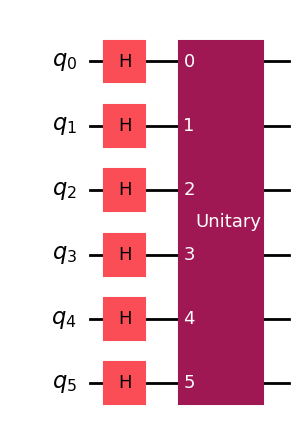

In [11]:
# Criando o circuito com um vetor qualquer do dataset para exemplificar

N_atributos=N_FEATURES 
'''
Numero de atributos do vetor a ser classificado. Adicionamos mais 1 ao numero obtido antes(pois temos o qubit alvo)
'''
#Escolhendo uma linha aleatória de X para podermos debugar
lista=[i for i in range(len(X_bc))]
j=int(np.random.choice(lista))

w=weights

#x=np.random.rand(N_atributos)
#w=np.random.rand(N_atributos)

N_qubits=N_QUBITS

#Podíamos inicializar assim pra facilitar as contas
'''x=np.random.rand(2**N_atributos)
w=np.random.rand(2**N_atributos)'''

# IQC

qc = QuantumCircuit(N_qubits)
qc.h(0) # Inicializaçao do estado inicial. Poderia ser qualquer estado.
qc.h(range(1,N_qubits))



#Montando os sigmas

matriz_pauli_x=np.array([[0,1],[1,0]]) # Matriz de Pauli x
matriz_pauli_y=np.array([[0,-1j],[1j,0]]) # Matriz de Pauli y
matriz_pauli_z=np.array([[1,0],[0,-1]]) # Matriz de Pauli z

sigmaQ=matriz_pauli_x+matriz_pauli_y+matriz_pauli_z



X_bc_new=list(X_bc[j])
if np.log2(N_atributos)%2!=0 and np.log2(N_atributos)!=1:
    for k in range(2**(N_qubits-1) - N_atributos):
        X_bc_new.append(0)
        w=np.append(w,0)
    sigmaE=np.diag(X_bc_new)*w.T
else:
    sigmaE=np.diag(X_bc_new)*w.T

#Debugando
print(f'X[{j}]:', X_bc_new, '; w:', w,'\n')
print('sigmaE')
print(sigmaE)
#Operador Unitário
U=np.matrix(expMatrix(1j*np.kron(sigmaQ,sigmaE)))

qubits=[i for i in range(N_qubits)]
# qubitstarget = [i for i in range(Ntarget)] - > Desnecessário agora, mas interessante para fazer a generalização
qc.unitary(U,qubits)
qc.draw("mpl")

In [12]:
#Decompondo em portas U3 e CX
qc = transpile(qc, optimization_level=3, basis_gates=["u3", "cx"])
print(dict(qc.count_ops()))
if dict(qc.count_ops())['u3']<=50 and dict(qc.count_ops())['u3']<=50:
    display(qc.draw('mpl'))

{'u3': 1494, 'cx': 982}


#### Statevector e Matriz Densidade

Aqui vamos avaliar o estado depois da evolução 

##### Statevector

<IPython.core.display.Latex object>

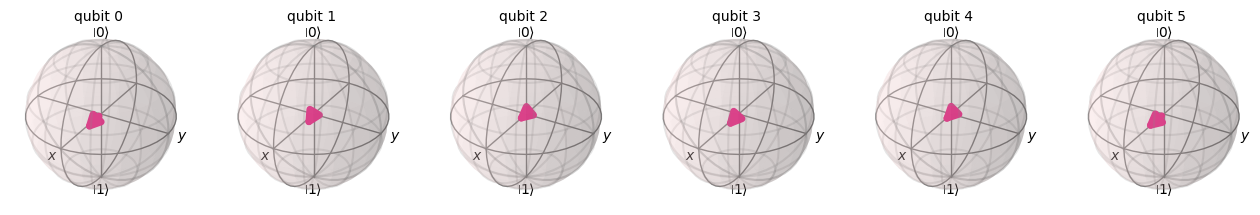

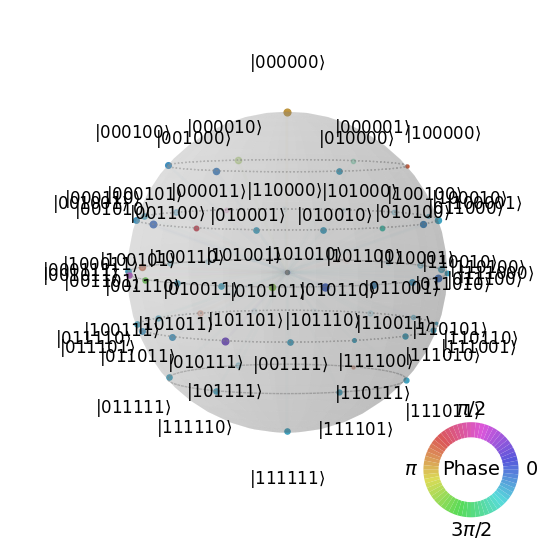

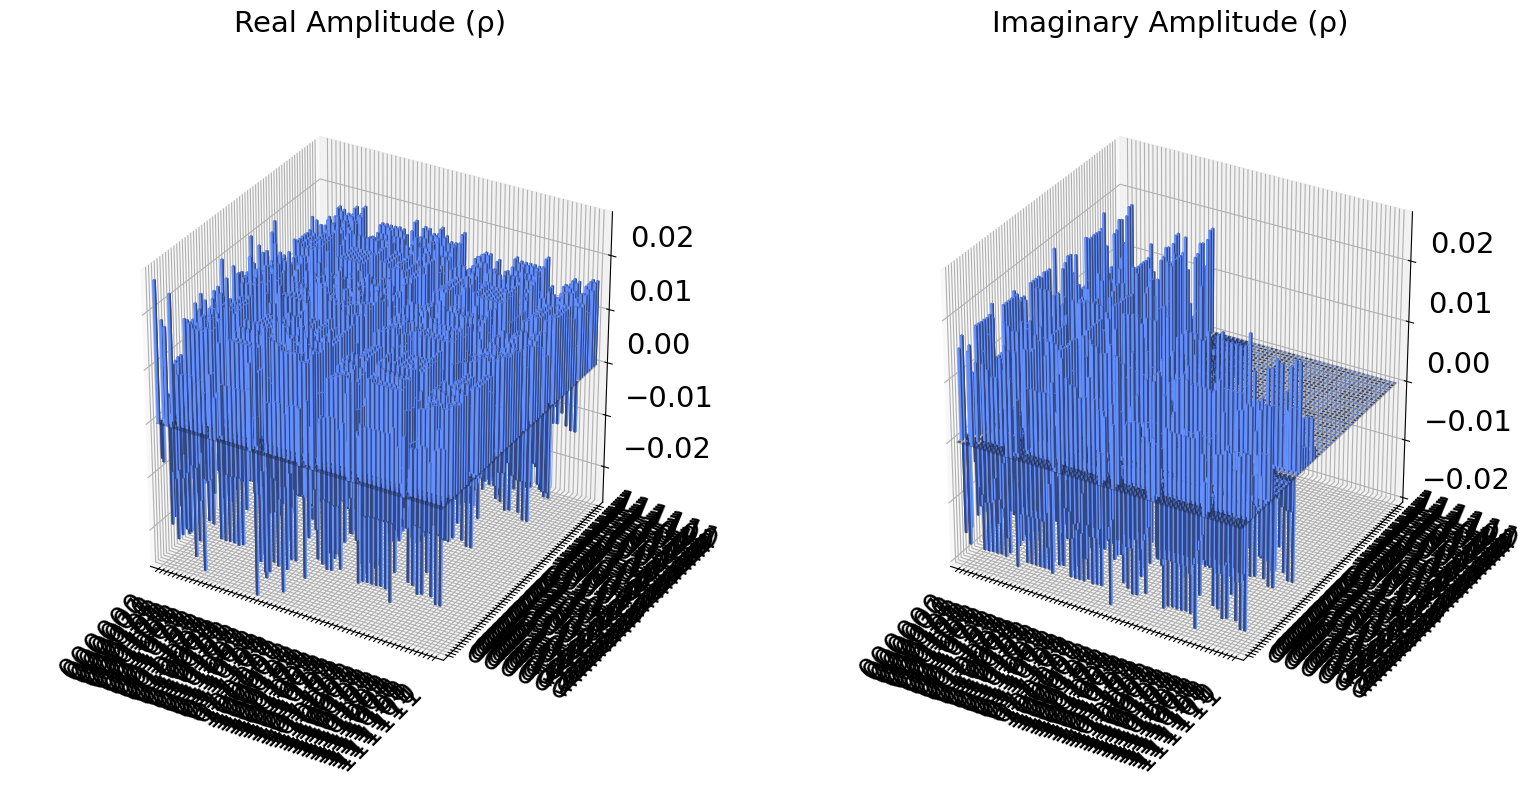

In [13]:
#Estado completo
sv = Statevector(qc)
'''
'mpl' is not a valid option for drawing Statevector objects. Please choose from:
            'text', 'latex', 'latex_source', 'qsphere', 'hinton',
            'bloch', 'city' or 'paulivec'
'''

display(sv.draw("latex")) #Plota o vetor de estado já em cada espaço de Hilbert
display(sv.draw("bloch")) #Plota o vetor de estado já em cada espaço de Hilbert
display(sv.draw("qsphere")) #Plota o vetor de estado em uma esfera que mapeia o espaço tensorial originado pelos espaços de Hilbert
display(sv.draw("city")) #Plota o histograma da matriz densidade SEM MEDÍ-LA


##### Partial Trace

Vamos traçar o sis. auxiliar

In [14]:
rho = partial_trace(sv,qubits[1:])
print(rho)

def blochvector(rho):
    x = np.trace(matriz_pauli_x@rho.data)
    y= np.trace(matriz_pauli_y@rho.data)
    z = np.trace(matriz_pauli_z@rho.data)
    return [x,y,z]
blochvector(rho)


DensityMatrix([[0.5       +0.j        , 0.27849996-0.02152269j],
               [0.27849996+0.02152269j, 0.5       +0.j        ]],
              dims=(2,))


[np.complex128(0.5569999111279812+0j),
 np.complex128(0.04304537896899088+0j),
 np.complex128(-3.3084646133829665e-14+0j)]

##### Ponto na Casca da superfície da Esfera de Bloch

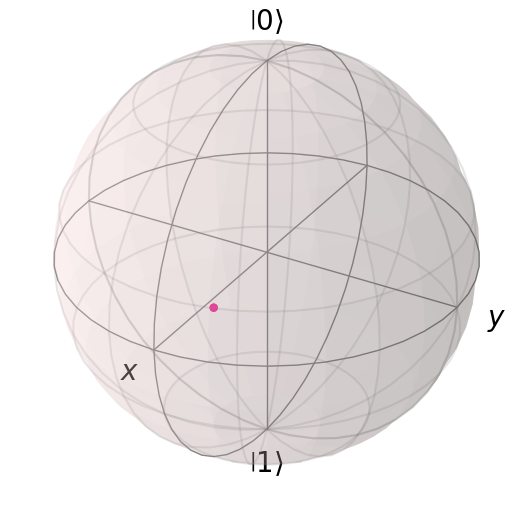

In [15]:
b = qutip.Bloch()
b.point_default_color=['deeppink']
b.add_points(blochvector(rho))

b.render()
b.show()

##### Matriz Densidade

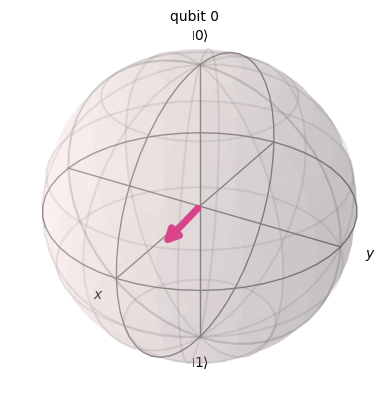

In [16]:
#Ao traçar fora o ambiente
rho_res = partial_trace(DensityMatrix.from_instruction(qc), qubits[1:])
#rho_res = partial_trace(DensityMatrix.from_instruction(qc), qubits[1:]).data

display(rho_res.draw('bloch'))

Como podemos observar, conseguimos marcar o ponto, na superfície da esfera, ao qual o autovetor do SISTEMA pertence. E se fizermos isso durante todo o código?

##### Negatividade

In [17]:
Negativity = (np.linalg.norm(rho_res)-1)/2

#### Executando o Circuito

{'011110': 15, '100100': 12, '111100': 9, '001101': 18, '110010': 12, '101110': 10, '000101': 27, '111011': 10, '001110': 17, '100101': 14, '000010': 20, '101011': 16, '110101': 7, '010110': 29, '111010': 11, '001111': 15, '100110': 22, '010101': 30, '011111': 18, '010011': 17, '110111': 11, '000000': 40, '000111': 17, '110000': 22, '001000': 18, '100111': 16, '010000': 11, '011101': 17, '011001': 15, '001010': 12, '111111': 26, '100001': 22, '001100': 14, '111101': 14, '100011': 24, '101000': 14, '010010': 17, '001001': 24, '010111': 21, '011000': 24, '000110': 16, '101111': 14, '110001': 15, '011100': 24, '011011': 18, '101100': 17, '110100': 15, '000011': 6, '011010': 18, '010001': 16, '111001': 12, '110011': 17, '000100': 14, '101101': 16, '100010': 7, '001011': 18, '111110': 19, '100000': 5, '101001': 10, '110110': 4, '000001': 9, '101010': 7, '111000': 11, '010100': 8}


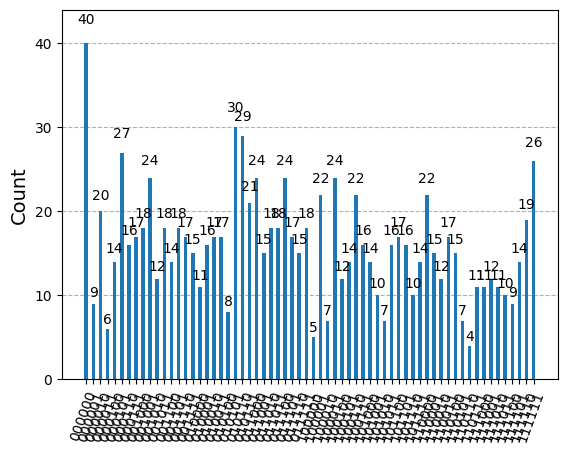

In [18]:
#Executar o circuito
def run_qasm_counts(circ, shots=1024):
  qc.measure_all()
  qasm_simulator = Aer.get_backend("qasm_simulator")
  job = qasm_simulator.run(qc, shots=shots)
  result = job.result()
  return result.get_counts()

counts = run_qasm_counts(qc)
print(counts)
plot_histogram(counts)

## Checando a Complexidade

In [6]:
def func(data,w=weights,qubits=QUBITS, N_qubits=N_QUBITS,N_atributos=N_FEATURES,printar_cirq=False):
    X_bc_new=list(data)
    if np.log2(N_atributos)%2!=0 and np.log2(N_atributos)!=1:
        for k in range(2**(N_qubits-1) - N_atributos):
            w=np.append(w,0)
            X_bc_new=np.append(X_bc_new,0)
        sigmaE=np.diag(X_bc_new)*w.T
    else:
        sigmaE=np.diag(X_bc_new)*w.T
    
    #Podíamos inicializar assim pra facilitar as contas
    '''x=np.random.rand(2**N_atributos)
    w=np.random.rand(2**N_atributos)'''

    # IQC:AIL

    qc = QuantumCircuit(N_qubits)

    qc.h(range(1,N_qubits))# Inicializaçao do estado inicial. Poderia ser qualquer estado.
    qc.h(0)


    #Montando os sigmas

    matriz_pauli_x=np.array([[0,1],[1,0]]) # Matriz de Pauli x
    matriz_pauli_y=np.array([[0,-1j],[1j,0]]) # Matriz de Pauli y
    matriz_pauli_z=np.array([[1,0],[0,-1]]) # Matriz de Pauli z

    sigmaQ=matriz_pauli_x+matriz_pauli_y+matriz_pauli_z

    

    #Operador Unitário
    U=np.matrix(expMatrix(1j*np.kron(sigmaQ,sigmaE)))

    # qubitstarget = [i for i in range(Ntarget)] - > Desnecessário agora, mas interessante para fazer a generalização
    qc.unitary(U,qubits)#display(qc.draw("mpl", filename='./mpl_original.pdf')) #Trocar as chamadas se quiser salvar as imagens dos circuitos

    #qc.decompose().draw(output="mpl", style="clifford")
    qc = transpile(qc, optimization_level=3, basis_gates=["u3", "cx"])

    if printar_cirq==True:
        print(dict(qc.count_ops()))
        display(qc.draw('mpl')) #display(qc.draw('mpl', filename='./mpl_transpile.pdf')) #Trocar as chamadas se quiser salvar as imagens dos circuitos

func(X_bc_iqc_coluna[0], printar_cirq=True)
func(X_bc_iqc_linha[0], printar_cirq=True)

{'u3': 1495, 'cx': 982}


ValueError: Image size of 2210x69012 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 2210.55x69012.6 with 1 Axes>

{'u3': 1495, 'cx': 982}


ValueError: Image size of 2210x69012 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 2210.55x69012.6 with 1 Axes>

## Função que gera o Quantum Circuit

In [ ]:
def blochvector(rho_cog,matriz_pauli_x,matriz_pauli_y,matriz_pauli_z):
    x_bloch = np.trace(matriz_pauli_x@rho_cog.data)
    y_bloch = np.trace(matriz_pauli_y@rho_cog.data)
    z_bloch = np.trace(matriz_pauli_z@rho_cog.data)
    return [x_bloch,y_bloch,z_bloch]
    
#Executar o circuito
def run_qasm_counts(qc, shots=N_SHOTS):
    qc.measure_all()
    qasm_simulator = Aer.get_backend("qasm_simulator")
    job = qasm_simulator.run(qc, shots=shots)
    result = job.result()
    return result.get_counts()

def cirq_iqc(data,contador,w=weights,qubits=QUBITS, N_qubits=N_QUBITS,N_atributos=N_FEATURES,printar_cirq=False):

    X_bc_new=list(data)
    if np.log2(N_atributos)%2!=0 and np.log2(N_atributos)!=1:
        for k in range(2**(N_qubits-1) - N_atributos):
            w=np.append(w,0)
            X_bc_new=np.append(X_bc_new,0)
        sigmaE=np.diag(X_bc_new)*w.T
    else:
        sigmaE=np.diag(X_bc_new)*w.T
    
    #Podíamos inicializar assim pra facilitar as contas
    '''x=np.random.rand(2**N_atributos)
    w=np.random.rand(2**N_atributos)'''

    # IQC

    qc = QuantumCircuit(N_qubits)

    qc.h(0)
    qc.h(range(1,N_qubits))



    #Montando os sigmas

    matriz_pauli_x=np.array([[0,1],[1,0]]) # Matriz de Pauli x
    matriz_pauli_y=np.array([[0,-1j],[1j,0]]) # Matriz de Pauli y
    matriz_pauli_z=np.array([[1,0],[0,-1]]) # Matriz de Pauli z

    sigmaQ=matriz_pauli_x+matriz_pauli_y+matriz_pauli_z

    

    #Operador Unitário
    U=np.matrix(expMatrix(1j*np.kron(sigmaQ,sigmaE)))

    # qubitstarget = [i for i in range(Ntarget)] - > Desnecessário agora, mas interessante para fazer a generalização
    qc.unitary(U,qubits)
    if contador==0:
        qc.draw("mpl", filename=f'./mpl_complete_U_bc_iqc.svg')
    if printar_cirq==True:
        display(qc.draw('mpl')) #display(qc.draw("mpl", filename='./mpl_original.pdf')) #Trocar as chamadas se quiser salvar as imagens dos circuitos

    #qc.decompose().draw(output="mpl", style="clifford")
    qc = transpile(qc, optimization_level=3, basis_gates=["u3", "cx"])
    if dict(qc.count_ops())['u3']<=50 and dict(qc.count_ops())['cx']<=50 and contador%N_PRINTINGS==0:
        qc.draw("mpl", filename=f'./mpl_transpiled{contador}_bc_iqc.svg')

    if printar_cirq==True and dict(qc.count_ops())['u3']<=50 and dict(qc.count_ops())['cx']<=50:
        print(dict(qc.count_ops()))
        display(qc.draw('mpl')) #display(qc.draw('mpl', filename='./mpl_transpile.pdf')) #Trocar as chamadas se quiser salvar as imagens dos circuitos

    # Mostrando o vetor de estado 
    sv = Statevector(qc)
    if contador%N_PRINTINGS==0:
        sv.draw("city", filename=f'./state_vector_city{contador}_bc_iqc.svg')
        sv.draw("bloch", filename=f'./state_vector_bloch{contador}_bc_iqc.svg')
        sv.draw("qsphere", filename=f'./state_vector_qsphere{contador}_bc_iqc.svg')
    if printar_cirq==True:
        display(sv.draw("latex"))
    
    counts = run_qasm_counts(qc)
    if contador%N_PRINTINGS==0:
        plot_histogram(counts,filename=f'./histogram_plot_{contador}_bc_iqc.svg')

    rho_cog = partial_trace(sv, qubits[1:])
    if printar_cirq==True:
        print(rho_cog)

    
    return blochvector(rho_cog,matriz_pauli_x,matriz_pauli_y,matriz_pauli_z)

## Esfera de Bloch do Circuito

In [8]:
def esfera_bloch_IQC(X,norma=None,weights=weights,printar_esf=False):
    point_states=[]
    for k in range(0,N_SAMPLES):
        point_states.append(cirq_iqc(X[k],k,w=weights))

    b = qutip.Bloch()
    b.point_default_color=['k']
    b.point_marker=['o']
    b.point_size=[15, 15, 15, 15]
    for k in range(len(point_states)):
        b.add_points(point_states[k])
    b.render()
    if printar_esf==True:
        b.show()

    bb = b.fig
    if norma:
        bb.savefig(f'Bloch_geral_bc_IQC_{norma}.svg')
    else:
        bb.savefig(f'Bloch_geral_bc_IQC.svg')

esfera_bloch_IQC(X_bc_iqc_coluna,'coluna')
esfera_bloch_IQC(X_bc_iqc_linha,'linha')
esfera_bloch_IQC(X_bc)


KeyboardInterrupt: 